## Hierarchical clustering

- is an unsupervised machine learning algorithm used to group similar data points into clusters

- It builds a tree-like structure (dendrogram) that represents the nested grouping of data points


![](https://media.datacamp.com/cms/ad_4nxe6kzluthg5vvtk_xxkfu90ygneu0akfmqr4bewt2xshyngpqdfivskm2ftwdhyy0uzfp7i3kdn2s2tkefomog_lywnjncsgjwftarhnvilirccjnrw9o3wcefdhbmny8ugne9koa.png)

- The two main types of hierarchical clustering are:
1. Agglomerative: 
- This method starts with individual data points and merges them into larger clusters

![](https://media.geeksforgeeks.org/wp-content/uploads/20260331113212178607/bottom_up_agglomerative_clustering_.webp)

2. Divisive: 
- This method starts with one large cluster and divides it into smaller clusters.

![](https://media.geeksforgeeks.org/wp-content/uploads/20260331113116081891/top_down_divisive_clustering_.webp)

While merging two clusters we check the distance between two every pair of clusters and merge the pair with the **least distance**/most similarity


Ways of defining Inter Cluster distance/similarity. Some of them are:

1. Min Distance: Find the minimum distance between any two points of the cluster

2. Max Distance: Find the maximum distance between any two points of the cluster.

3. Group Average: Find the average distance between every two points of the clusters

4. Ward's Method: The similarity of two clusters is based on the increase in squared error when two clusters are merged.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage

In [14]:
# Load the dataset
data = {
    'CustomerID': [1, 2, 3, 4, 5, 6],
    'Age': [25, 26, 60, 62, 22, 65],
    'SpendingScore': [80, 85, 15, 10, 88, 20]
}

df = pd.DataFrame(data)
print("--- Original Data ---")
print(df.head())

--- Original Data ---
   CustomerID  Age  SpendingScore
0           1   25             80
1           2   26             85
2           3   60             15
3           4   62             10
4           5   22             88


In [15]:
# Feature Selection - features that we want to cluster by
X = df[['Age','SpendingScore']]

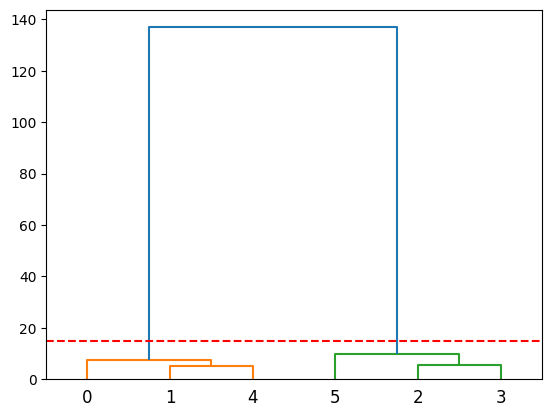

In [ ]:
# Create a Dendogram

# 1. Linkage
Z = linkage(X, method = 'ward')

# 2. Dendogram
dendrogram(Z)

# setting a threshold on the tree
plt.axhline(y = 15, c = 'r', linestyle = '--')

plt.show()


In [17]:
# Hierarchical Model 

hc_model = AgglomerativeClustering(
    n_clusters = 2, # where to cut the tree of hierarchy
    metric = 'euclidean',
    linkage = 'ward'
)

In [18]:
# train and predict using this model
clusters = hc_model.fit_predict(X)

df["H Clusters"] = clusters

In [19]:
df

,CustomerID,Age,SpendingScore,H Clusters
0,1,25,80,1
1,2,26,85,1
2,3,60,15,0
3,4,62,10,0
4,5,22,88,1
5,6,65,20,0


- Divisive clusetering you won't really find in Sci-Kit Learn because it is computationally intensive
- you have a large cluter of a big dataset, figuring out every possible way of splitting that data is tough for the computer
- 